# NBS CRM User Clustering

Monthly re-run: extract → preprocess → cluster → profile → export.
Spec: `docs/superpowers/specs/2026-05-18-crm-user-clustering-design.md`

In [1]:
import os
import warnings
from datetime import datetime

import hdbscan
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore", category=FutureWarning)
load_dotenv()

engine = create_engine(os.environ["READONLY_DATABASE_URL"], pool_pre_ping=True)
ANALYSIS_MONTH = datetime.now().strftime("%Y-%m")
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Analysis month: {ANALYSIS_MONTH}")
print("DB engine ready:", engine.url.host)

Analysis month: 2026-05
DB engine ready: ep-divine-band-ac36w1ss-pooler.sa-east-1.aws.neon.tech


In [2]:
# ── Users base ──────────────────────────────────────────────────────────────
sql_users = text("""
    SELECT
        u.id                                    AS user_id,
        u.kyc_level,
        u.status,
        u.created_at,
        u.last_active_at,
        (u.account_type = 'business')::int      AS account_type_business,
        COALESCE(p.onboarding_completed, FALSE)::int AS onboarding_completed
    FROM users u
    LEFT JOIN user_profiles p ON p.user_id = u.id
    WHERE u.status != 'suspended'
""")

df_users = pd.read_sql(sql_users, engine)
print(f"Users: {len(df_users):,}")
assert df_users["user_id"].nunique() == len(df_users), "Duplicate user_ids"
assert df_users["kyc_level"].between(0, 3).all(), "kyc_level out of range"
df_users.head(3)

Users: 16,485


,user_id,kyc_level,status,created_at,last_active_at,account_type_business,onboarding_completed
0,019d585b-78ee-70d1-878e-36d3701fa696,0,active,2026-04-04 11:58:02.990876+00:00,2026-04-04 11:58:02.990883+00:00,0,0
1,019c9f91-f7bd-7860-9bce-21564d32426b,0,active,2026-02-27 14:47:49.437590+00:00,2026-03-03 15:42:51.675536+00:00,0,1
2,0199cd50-a959-7a53-b716-9755e1856d7a,0,active,2025-10-10 08:50:39.577966+00:00,NaT,0,0


In [3]:
# ── Founders ─────────────────────────────────────────────────────────────────
sql_founders = text("""
    SELECT
        user_id,
        1                   AS is_founder,
        network_size        AS founder_network_size,
        invites_sent
    FROM founders
""")

df_founders = pd.read_sql(sql_founders, engine)
assert df_founders["user_id"].nunique() == len(df_founders), "Duplicate user_ids in founders"
assert (df_founders["founder_network_size"] >= 0).all(), "Negative network_size found"
assert (df_founders["invites_sent"] >= 0).all(), "Negative invites_sent found"
print(f"Founders: {len(df_founders):,}")
df_founders.head(3)

Founders: 16,500


,user_id,is_founder,founder_network_size,invites_sent
0,0199e451-2864-7553-83b9-e752d3a601c8,1,0,0
1,019a548a-5c7b-73e3-8e3d-d3cbc9326030,1,0,0
2,019ac322-10ea-79e2-8d9b-1e2bf4ab1e26,1,0,0


In [4]:
# ── Onramp / Offramp ─────────────────────────────────────────────────────────
# from_amount_brl is NULL on offramp rows; to_amount_brl is NULL on onramp rows.
# COALESCE(..., 0) before every SUM.
sql_conversions = text("""
    SELECT
        user_id,
        COUNT(*) FILTER (WHERE direction = 'brl_to_usdc')    AS n_onramp_txns,
        COUNT(*) FILTER (WHERE direction = 'usdc_to_brl')    AS n_offramp_txns,
        COALESCE(SUM(
            CASE WHEN direction = 'brl_to_usdc'
                 THEN COALESCE(from_amount_brl, 0) ELSE 0 END
        ) / 100.0, 0)                                        AS total_onramp_brl,
        COALESCE(SUM(
            COALESCE(spread_revenue_brl, 0) + COALESCE(fee_amount_brl, 0)
        ) / 100.0, 0)                                        AS total_spread_revenue_brl,
        COALESCE(
            SUM((processing_mode = 'instant')::int)::float
            / NULLIF(COUNT(*), 0), 0
        )                                                    AS pct_instant_mode,
        MAX(created_at)                                      AS last_conversion_at
    FROM conversion_quotes
    WHERE used = TRUE
    GROUP BY user_id
""")

df_conversions = pd.read_sql(sql_conversions, engine)
print(f"Users with conversions: {len(df_conversions):,}")
assert (df_conversions["total_spread_revenue_brl"] >= 0).all(), "Negative revenue"
assert df_conversions["user_id"].nunique() == len(df_conversions), "Duplicate user_ids"
df_conversions.head(3)

Users with conversions: 2,496


,user_id,n_onramp_txns,n_offramp_txns,total_onramp_brl,total_spread_revenue_brl,pct_instant_mode,last_conversion_at
0,019a138c-529e-7631-a353-287b96e99aa2,0,3,0.0,0.00,1.0,2026-04-22 07:47:17.981616+00:00
1,019c5e75-7ccf-71a1-9d51-99fc62d40c88,2,0,120.0,0.82,1.0,2026-02-15 00:06:27.281208+00:00
2,0199f1f5-d139-7c40-97c5-ce1be440c9c1,2,1,40.0,0.02,1.0,2025-12-03 11:53:37.180413+00:00


In [5]:
# ── Cards ────────────────────────────────────────────────────────────────────
sql_cards_txns = text("""
    SELECT
        user_id,
        COUNT(*) FILTER (
            WHERE transaction_type = 'spend' AND status = 'completed'
        )                                   AS n_card_txns,
        COALESCE(SUM(amount) FILTER (
            WHERE transaction_type = 'spend' AND status = 'completed'
        ) / 100.0, 0)                       AS total_card_spend_usd,
        MAX(authorized_at) FILTER (
            WHERE transaction_type = 'spend'
        )                                   AS last_card_spend_at
    FROM card_transactions
    WHERE user_id IS NOT NULL
    GROUP BY user_id
""")

sql_cards_issued = text("""
    SELECT
        user_id,
        1                                   AS has_card,
        MAX((card_variant = 'founder')::int) AS card_variant_founder
    FROM cards
    WHERE status = 'active'
    GROUP BY user_id
""")

sql_annual_fee = text("""
    SELECT DISTINCT user_id, 1 AS paid_annual_fee
    FROM card_annual_fees
    WHERE status = 'paid'
""")

df_card_txns   = pd.read_sql(sql_cards_txns, engine)
df_card_issued = pd.read_sql(sql_cards_issued, engine)
df_annual_fee  = pd.read_sql(sql_annual_fee, engine)

assert df_annual_fee["user_id"].nunique() == len(df_annual_fee), "Duplicate user_ids in annual_fee"

assert (df_card_txns["total_card_spend_usd"] >= 0).all(), "Negative card spend"
assert df_card_txns["user_id"].nunique() == len(df_card_txns), "Duplicate user_ids in card_txns"
assert df_card_issued["user_id"].nunique() == len(df_card_issued), "Duplicate user_ids in card_issued"

print(f"Users with card txns:   {len(df_card_txns):,}")
print(f"Users with active card: {len(df_card_issued):,}")
print(f"Users paid annual fee:  {len(df_annual_fee):,}")

Users with card txns:   1,077
Users with active card: 2,756
Users paid annual fee:  1,126


In [6]:
# ── Swaps + Solana ────────────────────────────────────────────────────────────
sql_swaps = text("""
    SELECT
        user_id,
        COUNT(*)                                            AS n_swaps,
        COALESCE(SUM(input_amount) / 1e6, 0)               AS total_swap_volume_usdc,
        COUNT(DISTINCT input_mint)
            + COUNT(DISTINCT output_mint)                   AS n_unique_tokens,
        MAX(timestamp)                                      AS last_swap_at
    FROM swap_transactions
    GROUP BY user_id
""")

sql_solana = text("""
    SELECT
        user_id,
        COUNT(DISTINCT transaction_signature) AS n_solana_txns
    FROM solana_sponsored_transactions
    GROUP BY user_id
""")

df_swaps  = pd.read_sql(sql_swaps, engine)
df_solana = pd.read_sql(sql_solana, engine)

assert df_swaps["user_id"].nunique() == len(df_swaps), "Duplicate user_ids in swaps"
assert (df_swaps["total_swap_volume_usdc"] >= 0).all(), "Negative swap volume"
assert df_solana["user_id"].nunique() == len(df_solana), "Duplicate user_ids in solana"

print(f"Users with swaps:  {len(df_swaps):,}")
print(f"Users with Solana: {len(df_solana):,}")

Users with swaps:  895
Users with Solana: 2,641


In [7]:
# ── AI sessions ──────────────────────────────────────────────────────────────
sql_ai = text("""
    SELECT
        user_id,
        COUNT(*)                        AS n_ai_sessions,
        COALESCE(SUM(message_count), 0) AS total_ai_messages
    FROM ai_sessions
    GROUP BY user_id
""")

# ── Notification engagement ───────────────────────────────────────────────
sql_notifications = text("""
    SELECT
        user_id,
        COUNT(*)                                        AS n_notifications_received,
        COUNT(*) FILTER (WHERE read_at IS NOT NULL)     AS n_notifications_read
    FROM notification_events
    GROUP BY user_id
""")

# ── International payouts ─────────────────────────────────────────────────
sql_international = text("""
    SELECT
        user_id,
        COUNT(*) FILTER (WHERE status = 'completed')        AS n_international_payouts,
        COALESCE(SUM(amount) FILTER (WHERE status = 'completed'), 0)
                                                            AS total_international_usdc
    FROM unblockpay_payouts
    GROUP BY user_id
""")

df_ai            = pd.read_sql(sql_ai, engine)
df_notifications = pd.read_sql(sql_notifications, engine)
df_international = pd.read_sql(sql_international, engine)

assert df_ai["user_id"].nunique() == len(df_ai), "Duplicate user_ids in ai"
assert df_notifications["user_id"].nunique() == len(df_notifications), "Duplicate user_ids in notifications"
assert (df_notifications["n_notifications_read"] <= df_notifications["n_notifications_received"]).all(), \
    "Read count exceeds received count"

print(f"Users with AI sessions:   {len(df_ai):,}")
print(f"Users with notifications: {len(df_notifications):,}")
print(f"Users with intl payouts:  {len(df_international):,}")

Users with AI sessions:   9,154
Users with notifications: 15,256
Users with intl payouts:  33


In [8]:
# ── Merge all sources onto user base (left joins — zero-fill = genuine non-usage) ─
df = df_users.copy()

for tbl in [
    df_founders,
    df_conversions,
    df_card_txns,
    df_card_issued,
    df_annual_fee,
    df_swaps,
    df_solana,
    df_ai,
    df_notifications,
    df_international,
]:
    df = df.merge(tbl, on="user_id", how="left")

print(f"Shape after merge: {df.shape}")
assert len(df) == len(df_users), "Row count changed after merges — check for duplicates"


Shape after merge: (16485, 33)


In [9]:
# ── Recency features ─────────────────────────────────────────────────────────
# DB datetimes are tz-aware UTC — strip timezone before .dt.days arithmetic
now = pd.Timestamp.now().normalize()

def recency_days(col):
    return (now - pd.to_datetime(df[col]).dt.tz_convert(None)).dt.days.fillna(9999).clip(upper=730)

df["days_since_signup"]          = recency_days("created_at")
df["days_since_last_active"]     = recency_days("last_active_at")
df["days_since_last_conversion"] = recency_days("last_conversion_at")
df["days_since_last_card_spend"] = recency_days("last_card_spend_at")
df["days_since_last_swap"]       = recency_days("last_swap_at")

# Zero-fill all numeric NaN (non-usage, not missing data)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols] = df[numeric_cols].fillna(0)

print("NaN remaining:", df[numeric_cols].isna().sum().sum())
assert df[numeric_cols].isna().sum().sum() == 0, "Unexpected NaN in numeric columns"


NaN remaining: 0


In [10]:
# ── Binary presence flags ────────────────────────────────────────────────────
df["has_onramp"]  = (df["n_onramp_txns"] > 0).astype(int)
df["has_offramp"] = (df["n_offramp_txns"] > 0).astype(int)
df["has_card"]    = df["has_card"].fillna(0).astype(int)
df["has_swap"]    = (df["n_swaps"] > 0).astype(int)
df["has_ai"]      = (df["n_ai_sessions"] > 0).astype(int)
df["has_intl"]    = (df["n_international_payouts"] > 0).astype(int)

# ── Product breadth score (0–6) ──────────────────────────────────────────────
df["product_breadth_score"] = (
    df["has_onramp"] + df["has_offramp"] + df["has_card"]
    + df["has_swap"] + df["has_ai"] + df["has_intl"]
)

# ── Revenue generated (spread only) ──────────────────────────────────────────
df["revenue_generated_brl"] = df["total_spread_revenue_brl"]

# ── Notification read rate ────────────────────────────────────────────────────
df["notification_read_rate"] = (
    df["n_notifications_read"]
    / df["n_notifications_received"].replace(0, np.nan)
).fillna(0)

print("Breadth score distribution:")
print(df["product_breadth_score"].value_counts().sort_index())


Breadth score distribution:
product_breadth_score
0    7351
1    5460
2    1519
3    1180
4     707
5     262
6       6
Name: count, dtype: int64


In [11]:
# ── Feature column lists ─────────────────────────────────────────────────────
LOG_FEATURES = [
    "n_onramp_txns", "n_offramp_txns", "total_onramp_brl",
    "total_spread_revenue_brl", "n_card_txns", "total_card_spend_usd",
    "n_swaps", "total_swap_volume_usdc", "n_unique_tokens",
    "n_solana_txns", "n_ai_sessions", "total_ai_messages",
    "n_notifications_received", "n_international_payouts",
    "total_international_usdc", "founder_network_size", "invites_sent",
    "revenue_generated_brl",
]

BINARY_FLAGS = [
    "has_onramp", "has_offramp", "has_card", "has_swap", "has_ai", "has_intl",
    "is_founder", "paid_annual_fee", "card_variant_founder",
    "onboarding_completed", "account_type_business",
]

NUMERIC_FEATURES = [
    "days_since_signup", "days_since_last_active", "days_since_last_conversion",
    "days_since_last_card_spend", "days_since_last_swap",
    "kyc_level", "product_breadth_score", "notification_read_rate",
    "pct_instant_mode",
]

ALL_FEATURES = LOG_FEATURES + BINARY_FLAGS + NUMERIC_FEATURES

X_raw = df[ALL_FEATURES].copy()

# log1p on skewed count/monetary features — must be non-negative (assert first)
assert (X_raw[LOG_FEATURES] >= 0).all().all(), "Negative values in log features"
X_raw[LOG_FEATURES] = np.log1p(X_raw[LOG_FEATURES])

print(f"Feature matrix shape: {X_raw.shape}")

Feature matrix shape: (16485, 38)


PCA: 13 components → 91.4% variance retained


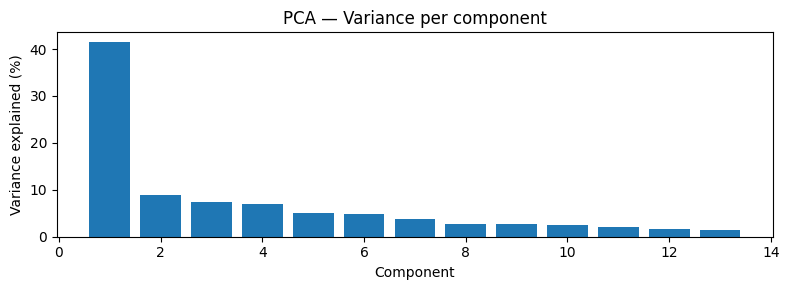

In [12]:
# ── Scale ────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ── PCA (retain 90% variance) ─────────────────────────────────────────────────
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

n_components = X_pca.shape[1]
variance_explained = pca.explained_variance_ratio_.sum()
print(f"PCA: {n_components} components → {variance_explained:.1%} variance retained")
assert 6 <= n_components <= 16, f"Unexpected component count: {n_components}"

# Variance explained per component (sanity check)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(1, n_components + 1), pca.explained_variance_ratio_ * 100)
ax.set(xlabel="Component", ylabel="Variance explained (%)",
       title="PCA — Variance per component")
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/crm_pca_variance_{ANALYSIS_MONTH}.png", dpi=120)
plt.show()

In [13]:
# ── Outlier quarantine ────────────────────────────────────────────────────────
detector = hdbscan.HDBSCAN(
    min_cluster_size=15, min_samples=5, metric="euclidean"
)
outlier_labels = detector.fit_predict(X_pca)
outlier_mask   = outlier_labels == -1

print(f"Outliers identified: {outlier_mask.sum()} ({outlier_mask.mean():.1%} of users)")

Outliers identified: 3788 (23.0% of users)


In [14]:
# ── Inspect outliers ──────────────────────────────────────────────────────────
# Are they bots, internal accounts, or data anomalies?
df_outliers = df[outlier_mask][[
    "user_id", "n_onramp_txns", "total_card_spend_usd",
    "n_swaps", "n_solana_txns", "days_since_last_active",
    "kyc_level", "product_breadth_score",
]].copy()

print(df_outliers.describe())
print(f"\nOutlier KYC distribution:\n{df_outliers['kyc_level'].value_counts()}")
print(f"\nOutlier breadth distribution:\n{df_outliers['product_breadth_score'].value_counts()}")

       n_onramp_txns  total_card_spend_usd      n_swaps  n_solana_txns  \
count    3788.000000           3788.000000  3788.000000    3788.000000   
mean        1.818902            240.028659     1.408659       6.673970   
std         8.507996           2210.532471    12.796341      34.207024   
min         0.000000              0.000000     0.000000       0.000000   
25%         0.000000              0.000000     0.000000       0.000000   
50%         0.000000              0.000000     0.000000       0.000000   
75%         0.000000              0.000000     0.000000       1.000000   
max       208.000000          62939.160000   472.000000     823.000000   

       days_since_last_active    kyc_level  product_breadth_score  
count             3788.000000  3788.000000            3788.000000  
mean                84.829989     1.445618               1.507920  
std                138.756396     0.895342               1.277123  
min                 -2.000000     0.000000               0.00

In [15]:
# ── Remove outliers before final clustering ───────────────────────────────────
X_pca_clean = X_pca[~outlier_mask]
X_raw_clean = X_raw[~outlier_mask].reset_index(drop=True)
df_clean    = df[~outlier_mask].copy().reset_index(drop=True)

print(f"Clean population: {len(df_clean):,} users ({outlier_mask.sum()} quarantined)")
assert len(df_clean) > 8_000, "Too many users quarantined — check HDBSCAN params"

Clean population: 12,697 users (3788 quarantined)


In [16]:
# ── K selection: silhouette + Davies-Bouldin + inertia ───────────────────────
k_results = []

for k in range(4, 12):
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = km.fit_predict(X_pca_clean)
    sil = silhouette_score(X_pca_clean, labels, sample_size=5_000, random_state=42)
    db  = davies_bouldin_score(X_pca_clean, labels)
    k_results.append({
        "k": k,
        "silhouette": sil,
        "davies_bouldin": db,
        "inertia": km.inertia_,
    })
    print(f"k={k}: silhouette={sil:.3f}  DB={db:.3f}  inertia={km.inertia_:.0f}")

results_df = pd.DataFrame(k_results)

k=4: silhouette=0.431  DB=0.913  inertia=154326
k=5: silhouette=0.442  DB=0.792  inertia=126556
k=6: silhouette=0.465  DB=0.919  inertia=100164
k=7: silhouette=0.471  DB=0.924  inertia=88394
k=8: silhouette=0.465  DB=0.949  inertia=77283
k=9: silhouette=0.482  DB=0.952  inertia=68653
k=10: silhouette=0.485  DB=0.979  inertia=64293
k=11: silhouette=0.485  DB=1.003  inertia=60341


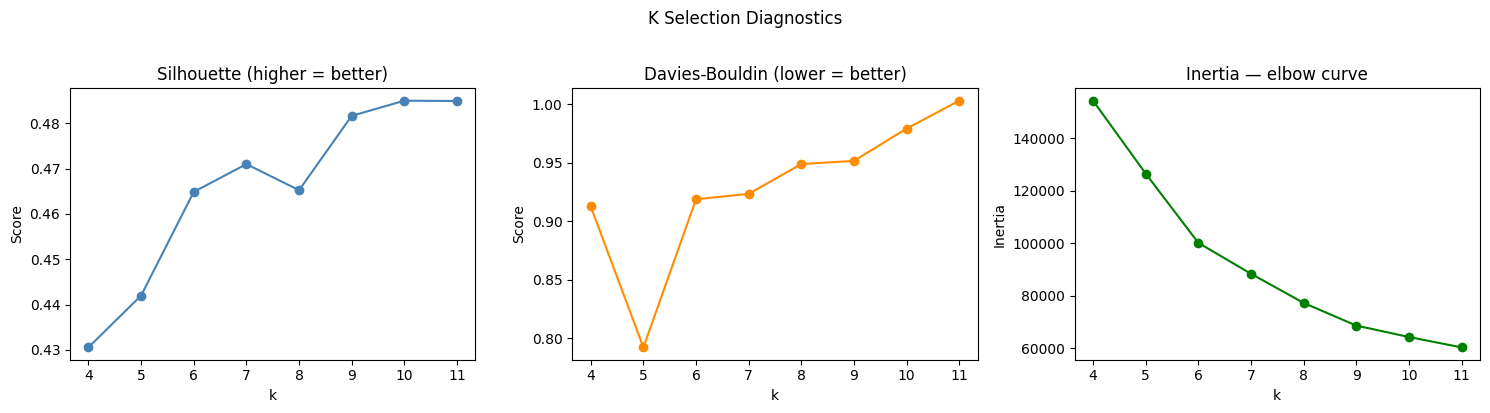


Best k by silhouette: 10
Review the elbow plot and confirm — override BEST_K below if needed.


In [17]:
# ── Diagnostic plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_df["k"], results_df["silhouette"], "o-", color="steelblue")
axes[0].set(title="Silhouette (higher = better)", xlabel="k", ylabel="Score")

axes[1].plot(results_df["k"], results_df["davies_bouldin"], "o-", color="darkorange")
axes[1].set(title="Davies-Bouldin (lower = better)", xlabel="k", ylabel="Score")

axes[2].plot(results_df["k"], results_df["inertia"], "o-", color="green")
axes[2].set(title="Inertia — elbow curve", xlabel="k", ylabel="Inertia")

plt.suptitle("K Selection Diagnostics", y=1.02)
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/crm_k_selection_{ANALYSIS_MONTH}.png", dpi=120)
plt.show()

best_k = int(results_df.loc[results_df["silhouette"].idxmax(), "k"])
print(f"\nBest k by silhouette: {best_k}")
print("Review the elbow plot and confirm — override BEST_K below if needed.")

In [18]:
# ── Set BEST_K here after reviewing the diagnostic plots ─────────────────────
# Default: silhouette peak. Override if elbow or business narrative suggests otherwise.
BEST_K = best_k   # change this integer if needed
print(f"Using BEST_K = {BEST_K}")

Using BEST_K = 10


In [19]:
# ── Final K-Means ─────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=BEST_K, init="k-means++", n_init=20, random_state=42)
km_labels = km_final.fit_predict(X_pca_clean)

df_clean["cluster_id"] = km_labels
print("Cluster sizes:")
print(df_clean["cluster_id"].value_counts().sort_index())

Cluster sizes:
cluster_id
0    2405
1    4147
2     179
3     373
4    4441
5     483
6      38
7      27
8     166
9     438
Name: count, dtype: int64


In [20]:
# ── GMM cross-validation ──────────────────────────────────────────────────────
gmm = GaussianMixture(
    n_components=BEST_K, covariance_type="full", n_init=5, random_state=42
)
gmm_labels = gmm.fit_predict(X_pca_clean)

ari = adjusted_rand_score(km_labels, gmm_labels)
print(f"K-Means vs GMM — Adjusted Rand Index: {ari:.3f}")
if ari >= 0.85:
    print("✓ Clusters are robust across algorithm choice (ARI ≥ 0.85)")
else:
    print("⚠ Clusters differ between K-Means and GMM — consider revisiting k or features")

K-Means vs GMM — Adjusted Rand Index: 0.642
⚠ Clusters differ between K-Means and GMM — consider revisiting k or features


In [21]:
# ── Stability across seeds ────────────────────────────────────────────────────
seed_labels = []
for seed in [0, 7, 13, 99, 2024]:
    km_tmp = KMeans(n_clusters=BEST_K, init="k-means++", n_init=10, random_state=seed)
    seed_labels.append(km_tmp.fit_predict(X_pca_clean))

ari_pairs = []
for i in range(len(seed_labels)):
    for j in range(i + 1, len(seed_labels)):
        ari_pairs.append(adjusted_rand_score(seed_labels[i], seed_labels[j]))

min_ari = min(ari_pairs)
print(f"Stability — min pairwise ARI across 5 seeds: {min_ari:.3f}")
if min_ari >= 0.85:
    print("✓ Cluster structure is stable (ARI ≥ 0.85 across seeds)")
else:
    print("⚠ Clusters are unstable — increase n_init or reduce BEST_K")

Stability — min pairwise ARI across 5 seeds: 0.829
⚠ Clusters are unstable — increase n_init or reduce BEST_K


In [22]:
# ── Cluster profiles in original (unscaled) feature space ─────────────────────
PROFILE_COLS = [
    "days_since_last_active", "days_since_signup", "kyc_level",
    "n_onramp_txns", "total_onramp_brl", "total_spread_revenue_brl",
    "n_card_txns", "total_card_spend_usd", "has_card",
    "n_swaps", "total_swap_volume_usdc", "n_solana_txns",
    "n_ai_sessions", "n_international_payouts",
    "product_breadth_score", "notification_read_rate",
    "founder_network_size", "onboarding_completed",
    "pct_instant_mode", "paid_annual_fee",
]

# Use original df values (before log transform) for interpretability
profile_mean   = df_clean.groupby("cluster_id")[PROFILE_COLS].mean().round(2)
profile_median = df_clean.groupby("cluster_id")[PROFILE_COLS].median().round(2)
cluster_sizes  = df_clean["cluster_id"].value_counts().rename("n_users").sort_index()

print("=== CLUSTER SIZES ===")
print(cluster_sizes)
print("\n=== CLUSTER MEANS (key features) ===")
key = ["days_since_last_active", "kyc_level", "n_onramp_txns", "n_card_txns",
       "n_swaps", "n_ai_sessions", "product_breadth_score", "total_spread_revenue_brl"]
print(profile_mean[key])


=== CLUSTER SIZES ===
cluster_id
0    2405
1    4147
2     179
3     373
4    4441
5     483
6      38
7      27
8     166
9     438
Name: n_users, dtype: int64

=== CLUSTER MEANS (key features) ===
            days_since_last_active  kyc_level  n_onramp_txns  n_card_txns  \
cluster_id                                                                  
0                           134.22       0.03           0.00         0.00   
1                            60.07       1.51           0.00         0.00   
2                            20.81       2.00           2.62        15.64   
3                            44.79       1.98           2.39         0.11   
4                           707.37       0.00           0.00         0.00   
5                            46.95       1.99           1.12         0.13   
6                            38.84       1.37           0.76         0.00   
7                            21.04       2.00          10.11        44.41   
8                            17

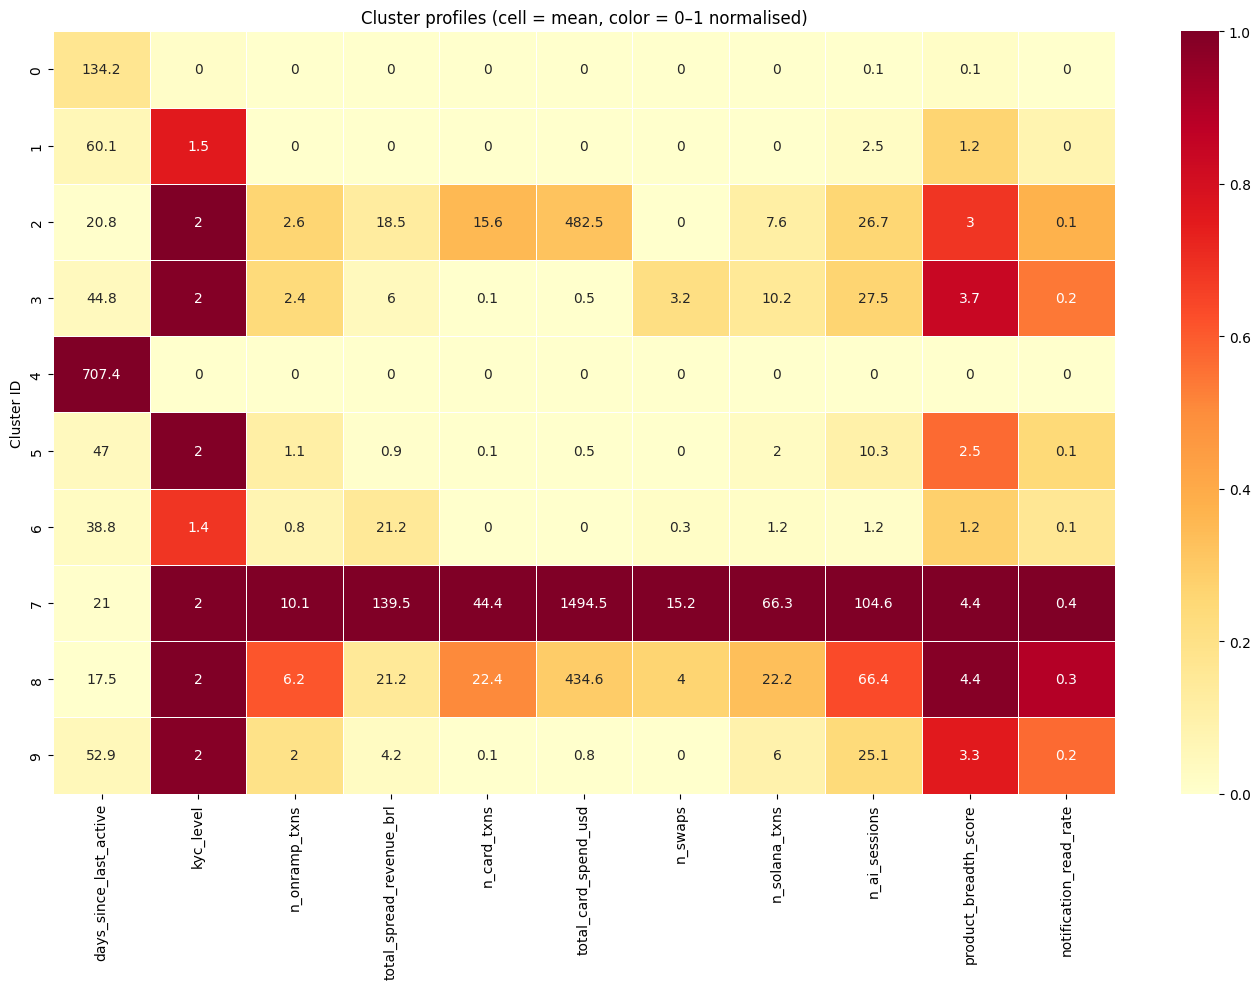

In [23]:
# ── Cluster heatmap ───────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

heatmap_cols = [
    "days_since_last_active", "kyc_level", "n_onramp_txns",
    "total_spread_revenue_brl", "n_card_txns", "total_card_spend_usd",
    "n_swaps", "n_solana_txns", "n_ai_sessions",
    "product_breadth_score", "notification_read_rate",
]

heat_data = profile_mean[heatmap_cols].copy()
# Normalise 0–1 per column for visual comparison
heat_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(heat_data),
    index=heat_data.index,
    columns=heat_data.columns,
)

fig, ax = plt.subplots(figsize=(14, max(4, BEST_K)))
sns.heatmap(heat_norm, annot=profile_mean[heatmap_cols].values.round(1),
            fmt="g", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set(title="Cluster profiles (cell = mean, color = 0–1 normalised)")
ax.set_ylabel("Cluster ID")
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/crm_cluster_heatmap_{ANALYSIS_MONTH}.png", dpi=120)
plt.show()


In [ ]:
# ── Assign segment names ──────────────────────────────────────────────────────
# Review the heatmap and cluster profiles above, then map cluster_id → name.
# This mapping MUST be updated after every full re-fit — cluster IDs shift.
# Expected archetypes (adjust to match your actual cluster profiles):
#   power_onramper     → high n_onramp_txns, high revenue, low days_since_active
#   card_spender       → high n_card_txns, paid_annual_fee=1, lower onramp
#   defi_trader        → high n_swaps, high n_unique_tokens, high n_solana_txns
#   occasional_onramer → 1–5 onramp txns, breadth=1, days_since_active 30–90
#   explorer_ai        → high n_ai_sessions, low financial txns
#   stalled_pre_kyc    → kyc_level≤1, onboarding=0, all activity=0
#   dormant            → days_since_active>90, some past activity

SEGMENT_NAMES = {
    0: "stalled_pre_kyc",    # ← replace with actual mapping after reviewing heatmap
    1: "occasional_onramer",
    2: "power_onramper",
    3: "card_spender",
    4: "explorer_ai",
    5: "defi_trader",
    6: "dormant",
}

# Auto-pad any cluster IDs beyond the manually defined entries with generic names.
# Replace these placeholders after reviewing the heatmap for each extra cluster.
for _k in range(BEST_K):
    if _k not in SEGMENT_NAMES:
        SEGMENT_NAMES[_k] = f"segment_{_k}"

assert set(SEGMENT_NAMES.keys()) == set(range(BEST_K)), \
    f"SEGMENT_NAMES keys must match cluster IDs 0..{BEST_K-1}"
assert len(set(SEGMENT_NAMES.values())) == BEST_K, "Segment names must be unique"

df_clean["segment_name"] = df_clean["cluster_id"].map(SEGMENT_NAMES)
print(df_clean["segment_name"].value_counts())

In [ ]:
# ── UMAP 2D projection (visualization only — not used for clustering) ─────────
print("Running UMAP... (~1–2 min)")
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_2d = reducer.fit_transform(X_pca_clean)

df_clean["umap_x"] = X_2d[:, 0]
df_clean["umap_y"] = X_2d[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette("tab10", n_colors=BEST_K)
for seg_id, seg_name in SEGMENT_NAMES.items():
    mask = df_clean["cluster_id"] == seg_id
    ax.scatter(
        df_clean.loc[mask, "umap_x"],
        df_clean.loc[mask, "umap_y"],
        s=6, alpha=0.5, color=palette[seg_id],
        label=f"{seg_id}: {seg_name} (n={mask.sum():,})",
    )
ax.legend(loc="upper right", fontsize=8, markerscale=3)
ax.set(title=f"NBS User Segments — UMAP projection ({ANALYSIS_MONTH})",
       xlabel="UMAP-1", ylabel="UMAP-2")
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/crm_umap_{ANALYSIS_MONTH}.png", dpi=150)
plt.show()

In [ ]:
# ── Push notification message library ────────────────────────────────────────
# Three time-of-day slots: morning (07–09h BRT), afternoon (12–14h BRT),
#                          evening (19–21h BRT)
# Each segment has 2–3 message variants per slot.

MESSAGES = {
    "power_onramper": {
        "campaign_goal": "Cross-sell DeFi swaps and card. VIP framing — never discount.",
        "morning": [
            ("Alerta de taxa", "Comece o dia forte — seu BRL está pronto para converter na melhor taxa de hoje."),
        ],
        "afternoon": [
            ("Taxa favorável", "BRL/USDC está atraente agora. Converta em 60 segundos."),
        ],
        "evening": [
            ("USDC parado?", "Seu USDC está parado — que tal uma swap no Jupiter para fazer seu portfólio crescer?"),
        ],
    },
    "card_spender": {
        "campaign_goal": "Onramp cross-sell. They trust the card — remove friction to first conversion.",
        "morning": [
            ("Recarregue seu cartão", "Recarregue seu cartão NBS em 60 segundos — adicione BRL via PIX e converta na hora."),
        ],
        "afternoon": [
            ("Recarregue agora", "Seu cartão está pronto para usar. Complete com PIX e nunca fique sem saldo."),
        ],
        "evening": [
            ("Recarga rápida", "Recarga rápida antes de amanhã? PIX → USDC em menos de um minuto."),
        ],
    },
    "defi_trader": {
        "campaign_goal": "Deepen swap engagement. DeFi-native language only — no BRL/USDC pitch.",
        "morning": [
            ("Nova liquidez", "Nova liquidez no Jupiter — veja as melhores rotas de swap de hoje."),
        ],
        "afternoon": [
            ("Portfólio em movimento", "Seu portfólio está se movendo. Troque tokens sem taxas escondidas na NBS."),
        ],
        "evening": [
            ("DeFi não para", "DeFi não para. Viu uma oportunidade? Faça a swap agora."),
        ],
    },
    "occasional_onramer": {
        "campaign_goal": "Cross-sell depth — they onramp but stop there. Push the next product.",
        "morning": [
            ("USDC parado", "Seu USDC está parado — coloque-o para trabalhar com uma swap ou seu cartão NBS."),
        ],
        "afternoon": [
            ("Faz tempo...", "Faz tempo desde a sua última conversão. As taxas estão ótimas hoje."),
        ],
        "evening": [
            ("Próximo passo", "Mais um passo para desbloquear sua carteira NBS completa — faça uma swap ou solicite seu cartão."),
        ],
    },
    "explorer_ai": {
        "campaign_goal": "First conversion activation — they know the product, remove friction.",
        "morning": [
            ("Carteira pronta", "Sua carteira NBS está pronta — compre USDC com PIX e desbloqueie seu cartão hoje."),
        ],
        "afternoon": [
            ("Primeira conversão", "Você tem explorado a NBS — pronto para fazer sua primeira conversão BRL → USDC?"),
        ],
        "evening": [
            ("A um PIX de distância", "Sua conta está configurada. Uma transferência PIX e você está ativo."),
        ],
    },
    "stalled_pre_kyc": {
        "campaign_goal": "KYC funnel completion. Minimal copy, single CTA.",
        "delivery_rule": "Only send if device_tokens.is_active = TRUE.",
        "morning": [
            ("Verifique agora", "Verifique em 2 minutos — acesse BRL ↔ USDC em tempo real."),
        ],
        "afternoon": [
            ("Conta aguardando", "Sua conta NBS está esperando. Conclua a verificação para começar."),
        ],
        "evening": [
            ("2 minutos", "Leva 2 minutos. Depois é só usar a NBS."),
        ],
    },
    "dormant": {
        "campaign_goal": "Win-back. One send per quarter maximum.",
        "delivery_rule": "Skip if notification_read_rate = 0 over last 90 days.",
        "morning": [
            ("Novidades na NBS", "Temos novidades — a NBS ganhou recursos novos desde sua última visita."),
        ],
        "afternoon": [
            ("Saldo esperando", "Seu saldo está esperando. Entre e veja o que mudou."),
        ],
        "evening": [
            ("Ainda aqui", "Faz um tempo. Seu USDC ainda está aqui quando você quiser."),
        ],
    },
}

# Validate template coverage matches segment names
assert set(MESSAGES.keys()) == set(SEGMENT_NAMES.values()), \
    f"MESSAGES keys must match SEGMENT_NAMES values.\nMissing: {set(SEGMENT_NAMES.values()) - set(MESSAGES.keys())}"

print("Message template library validated.")
for seg, data in MESSAGES.items():
    print(f"  {seg}: {data['campaign_goal'][:60]}")

In [ ]:
# ── Cross-join with active push tokens ───────────────────────────────────────
sql_pushable = text("""
    SELECT DISTINCT user_id
    FROM device_tokens
    WHERE is_active = TRUE
""")
df_pushable = pd.read_sql(sql_pushable, engine)
print(f"Users with active push token: {len(df_pushable):,}")

crm_export = (
    df_clean[["user_id", "cluster_id", "segment_name",
              "notification_read_rate", "days_since_last_active"]]
    .merge(df_pushable, on="user_id", how="inner")
)

# Apply delivery rule for dormant: skip if notification_read_rate = 0
dormant_mask = (
    (crm_export["segment_name"] == "dormant")
    & (crm_export["notification_read_rate"] == 0)
)
crm_export = crm_export[~dormant_mask].copy()

print(f"Pushable users after delivery rules: {len(crm_export):,}")
print(crm_export["segment_name"].value_counts())

In [ ]:
# ── Save CRM export CSV ───────────────────────────────────────────────────────
# No PII — user_id only. Gitignored.
export_path = f"{PROCESSED_DIR}/crm_segments_{ANALYSIS_MONTH}.csv"
crm_export[["user_id", "cluster_id", "segment_name"]].to_csv(export_path, index=False)
print(f"CRM export saved: {export_path} ({len(crm_export):,} rows)")

In [ ]:
# ── Save model artifacts for incremental scoring ──────────────────────────────
joblib.dump(scaler,        f"{PROCESSED_DIR}/crm_scaler_{ANALYSIS_MONTH}.pkl")
joblib.dump(pca,           f"{PROCESSED_DIR}/crm_pca_{ANALYSIS_MONTH}.pkl")
joblib.dump(km_final,      f"{PROCESSED_DIR}/crm_kmeans_{ANALYSIS_MONTH}.pkl")
joblib.dump(SEGMENT_NAMES, f"{PROCESSED_DIR}/crm_segment_names_{ANALYSIS_MONTH}.pkl")

print("Saved artifacts:")
for suffix in ["scaler", "pca", "kmeans", "segment_names"]:
    path = f"{PROCESSED_DIR}/crm_{suffix}_{ANALYSIS_MONTH}.pkl"
    print(f"  {path}")

print("To score new users:")
print("  scaler = joblib.load(scaler_path)")
print("  pca    = joblib.load(pca_path)")
print("  km     = joblib.load(kmeans_path)")
print("  names  = joblib.load(segment_names_path)")
print("  X_new_pca = pca.transform(scaler.transform(X_new_log1p))")
print("  labels    = km.predict(X_new_pca)")